Epoch 1/20 | Train Loss: 1.0995 | Val Loss: 1.0988
Epoch 2/20 | Train Loss: 1.0989 | Val Loss: 1.0987
Epoch 3/20 | Train Loss: 1.0986 | Val Loss: 1.0988
Epoch 4/20 | Train Loss: 1.0989 | Val Loss: 1.0987
Epoch 5/20 | Train Loss: 1.0989 | Val Loss: 1.0986
Epoch 6/20 | Train Loss: 1.0998 | Val Loss: 1.0986
Epoch 7/20 | Train Loss: 1.0988 | Val Loss: 1.0986
Epoch 8/20 | Train Loss: 1.0990 | Val Loss: 1.0985
Epoch 9/20 | Train Loss: 1.1002 | Val Loss: 1.0986
Epoch 10/20 | Train Loss: 1.0979 | Val Loss: 1.0985
Epoch 11/20 | Train Loss: 1.0978 | Val Loss: 1.0984
Epoch 12/20 | Train Loss: 1.0971 | Val Loss: 1.0984
Epoch 13/20 | Train Loss: 1.0973 | Val Loss: 1.0986
Epoch 14/20 | Train Loss: 1.0966 | Val Loss: 1.0998
Epoch 15/20 | Train Loss: 1.0967 | Val Loss: 1.1006
Epoch 16/20 | Train Loss: 1.0956 | Val Loss: 1.1041
Epoch 17/20 | Train Loss: 1.0956 | Val Loss: 1.1059
Epoch 18/20 | Train Loss: 1.0954 | Val Loss: 1.1255
Epoch 19/20 | Train Loss: 1.0955 | Val Loss: 1.1255
Epoch 20/20 | Train L

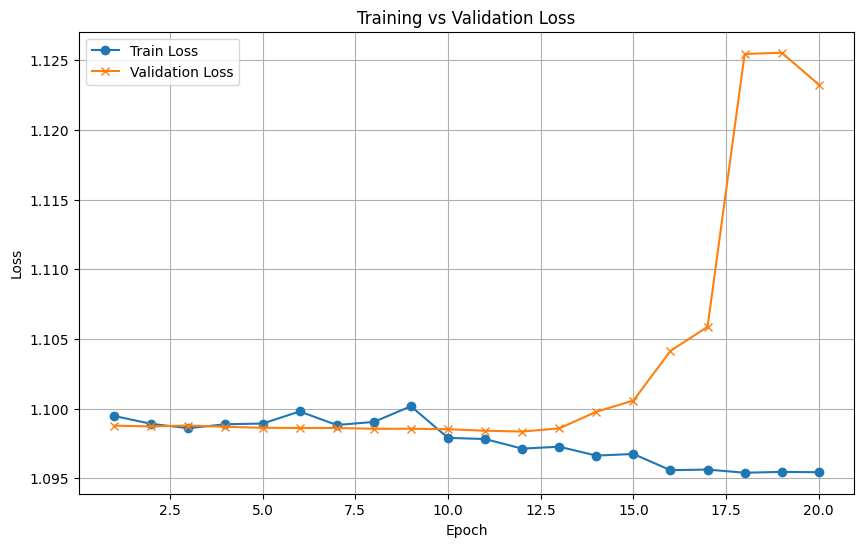

Validation Accuracy: 0.3328


In [8]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# -----------------------------
# Load NPZ
# -----------------------------
data = np.load("mfcc_lstm_sequences.npz")
X = data["X"]  # shape: (num_samples, time_steps, n_mfcc)
y = data["y"]  # labels as strings

# Flatten MFCC sequences for ANN input
X_flat = X.reshape(X.shape[0], -1)

# Encode labels
le = LabelEncoder()
y_enc = le.fit_transform(y)
num_classes = len(le.classes_)

# Train/Validation split
X_train, X_val, y_train, y_val = train_test_split(
    X_flat, y_enc, test_size=0.12, random_state=42, stratify=y_enc
)

# -----------------------------
# PyTorch Dataset
# -----------------------------
class MFCCDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self):
        return len(self.y)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(MFCCDataset(X_train, y_train), batch_size=16, shuffle=True)
val_loader = DataLoader(MFCCDataset(X_val, y_val), batch_size=16, shuffle=False)

# -----------------------------
# Deep ANN Model
# -----------------------------
class DeepANN(nn.Module):
    def __init__(self, input_size, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 16),
            nn.ReLU(),
            nn.Linear(16, 32),
            nn.ReLU(),
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, num_classes)
        )
    def forward(self, x):
        return self.net(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DeepANN(X_flat.shape[1], num_classes=num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# -----------------------------
# Training Loop with Loss Tracking
# -----------------------------
EPOCHS = 20
train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    avg_train_loss = total_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Validation
    model.eval()
    val_total_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            val_total_loss += loss.item()
    avg_val_loss = val_total_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

# -----------------------------
# Plot Training vs Validation Loss
# -----------------------------
plt.figure(figsize=(10,6))
plt.plot(range(1, EPOCHS+1), train_losses, label='Train Loss', marker='o')
plt.plot(range(1, EPOCHS+1), val_losses, label='Validation Loss', marker='x')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.grid(True)
plt.legend()
plt.show()
model.eval()
preds, trues = [], []
with torch.no_grad():
    for X_batch, y_batch in val_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        logits = model(X_batch)
        pred = torch.argmax(logits, dim=1)
        preds.extend(pred.cpu().tolist())
        trues.extend(y_batch.cpu().tolist())

acc = accuracy_score(trues, preds)
print(f"Validation Accuracy: {acc:.4f}")